# Lab 5 : Introduction to the bootstrap

In [2]:
import numpy as np  # math library
import pandas as pd  # Library to handle databases
import matplotlib.pyplot as plt  # Graphic library
from scipy import stats  # stat library
import seaborn as sns  # Graphic library specialized in stats
import statsmodels.api as sm  # statistic modelling library

## Galaxy data

Description of the dataset: a numeric vector of velocities in km/sec of 82 galaxies from 6 well-separated conic sections of an unfilled survey of the Corona Borealis constellation. Multimodality in such surveys is evidence for voids and superclusters in the far universe.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/ae/Corona_Borealis_IAU.svg/1222px-Corona_Borealis_IAU.svg.png" width="500"/>
<img src='https://render.fineartamerica.com/images/rendered/share/24512089&domainId=1' width="500"'>

The study of the velocities of stars can teach us some properties of the stars in question, see https://en.wikipedia.org/wiki/Stellar_kinematics#Use_of_kinematic_measurements.

In [3]:
df = sm.datasets.get_rdataset("galaxies", "MASS").data

In [4]:
len(df)

82

In [5]:
df

,dat
0,9172
1,9350
2,9483
3,9558
4,9775
...,...
77,26690
78,26995
79,32065
80,32789


### Question 1
Give a graphical representation of the empirical distribution of velocities of stars. Does a Gaussian model fit well these data?

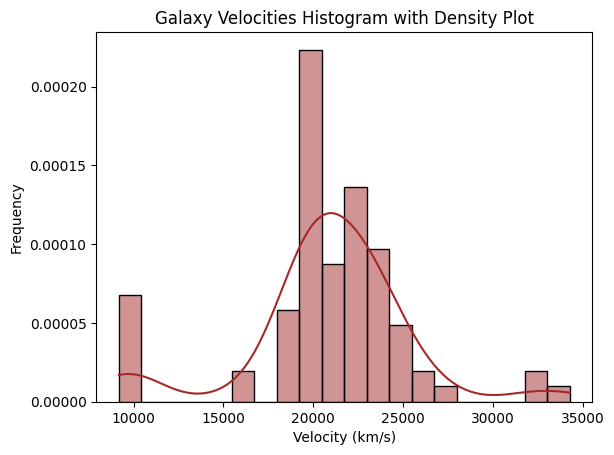

In [18]:
# Plot histogram and density
sns.histplot(df['dat'], bins=20,alpha=0.5,kde=True, color='brown', stat='density') 
plt.title('Galaxy Velocities Histogram with Density Plot')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Frequency')
plt.show()

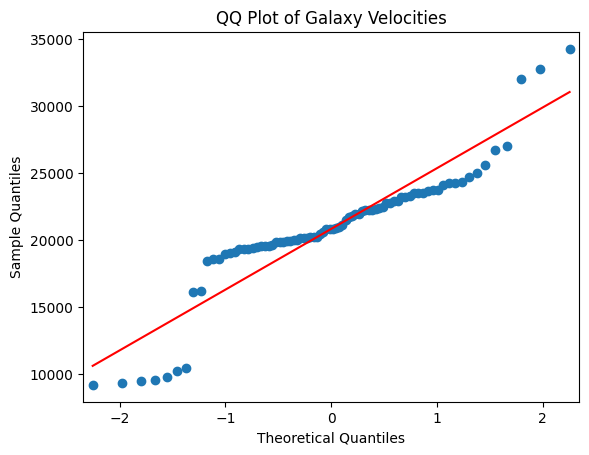

In [21]:
# make a QQ plot (find out what it is)
sm.qqplot(df['dat'], line ='s')
plt.title('QQ Plot of Galaxy Velocities')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

This dataset is not unimodal and not suitable for a Gaussian model and in fact we will not use a specific model as this dataset is not easy to model. Instead we will use Boostrap methods that allow for a non-parametric study of the dataset.

### Goal of the estimation

In this practical session, we will try to see the properties of the majority of the stars (the central peak in the histogram) as this exhibits the properties of the principal stars of the constellation. To do that we will study the median of the distribution.

It can be intuitively understood that in this application, the sample mean is not very interesting because it will be too easily influenced by the extreme points which are atypical stars (that are very heavy or very light); on the other hand the sample median is a more robust location parameter, that does not give undue weight to atypical stars.

Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, we estimate the standard error and the law of the median using the bootstrap.

### Question 2
Let $X_1,\dots,X_n$ be the observations `df['dat']`, compute the empirical median $\widehat m = Med(X_1,\dots,X_n)$.

Generate a bootstrap sample from $X_1,\dots,X_n$ and print its median $\widehat{m}^*$. Plot the histogram of the bootstrap sample and compare it with the histogram of `df['dat']`.

20833.5 20315.0


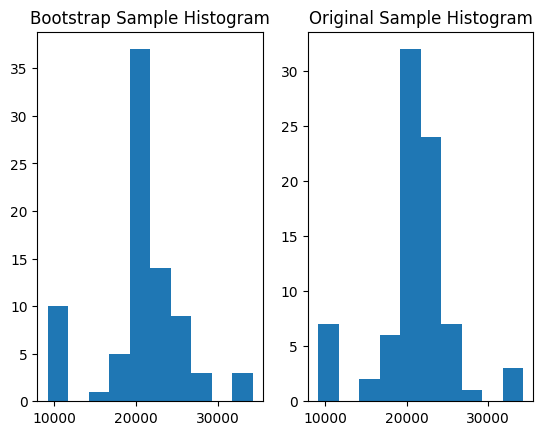

In [24]:
n = len(df)
m_hat = np.median(df['dat']) # Compute the median of the dataset
sample_boot = np.random.choice(df['dat'], size=n, replace=True) # Generate a bootstrap sample using np.random.choice
m_boot = np.median(sample_boot) # Compute the median of the bootstrap sample
print(m_hat, m_boot)

plt.subplot(1, 2, 1)
plt.hist(sample_boot)
plt.title('Bootstrap Sample Histogram')
plt.subplot(1, 2, 2)
plt.hist(df['dat'])
plt.title('Original Sample Histogram')
plt.show()


### Question 3

Compute $B=1000$ bootstrap estimates of the median from $B$ bootstrap samples; we will denote them by $\widehat{m}^*_1,\dots,\widehat{m}^*_B$.

Plot the histogram of the $\widehat{m}^*_i$'s and show the location of $\widehat m$ on this plot. This histogram is the bootstrap sampling distribution which is an estimator of the unknown distribution of the sample median.

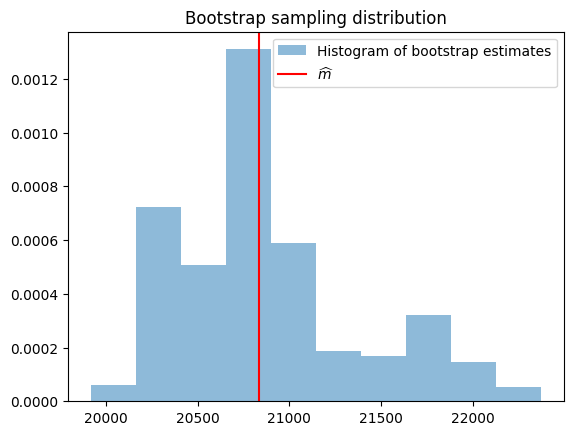

In [30]:
B = 1000
result = []
for b in range(B):
    sample_boot = np.random.choice(df['dat'],size=len(df),replace=True) # Generate a bootstrap sample using np.random.choice
    result.append(np.median(sample_boot)) # Compute the median of the bootstrap sample and store it in result

m_hat = np.median(df['dat']) # Compute the median of the dataset

plt.hist(result, density=True, label='Histogram of bootstrap estimates', alpha=0.5)
plt.axvline(m_hat, 0, 1, c='r', label=r"$\widehat{m}$")
plt.title("Bootstrap sampling distribution")
plt.legend()

### Question 4

Estimate the MSE of $\widehat m$ by computing the bias and the variance of the bootstrap sampling distribution.

In [31]:
bias = np.mean(result)-m_hat # Compute the bias of the bootstrap sampling distribution
variance = np.var(result,ddof=1) # Compute the variance of the bootstrap sampling distribution
MSE = bias ** 2 + variance
print('An estimation of the bias is given by: %.2F km/s' % (bias))
print('An estimation of the standard deviation is given by: %.2F km/s' % (np.sqrt(variance)))
print('An estimation of the root MSE (RMSE) is given by: %.2F km/s' % (np.sqrt(MSE)))

An estimation of the bias is given by: 41.09 km/s
An estimation of the standard deviation is given by: 509.20 km/s
An estimation of the root MSE (RMSE) is given by: 510.86 km/s


## Bootstrap confidence interval
### Question 5
Give the empirical quantiles of level $0.05$ and $0.95$ for the bootstrap distribution of $\widehat m^*-\widehat m$ (use np.quantile). Deduce a bootstrap confidence interval for the median with level $0.90$.

In [33]:
q1 = np.quantile(result - m_hat, 0.05) # Compute the 0.05 quantile of the bootstrap sampling distribution
q2 = np.quantile(result - m_hat, 0.95) # Compute the 0.95 quantile of the bootstrap sampling distribution
print("The confidence interval of m is [%.2F,%.2F]" % (m_hat - q2, m_hat - q1))

The confidence interval of m is [19799.50,21481.50]


### To go further : Study of the Supercluster

<img src="https://nineplanets.org/wp-content/uploads/2020/08/Corona-Borealis-Supercluster.jpg" width="300"/>

From "Postman, M., Huchra, J. P. and Geller, M. J. (1986) Probes of large-scale structures in the Corona Borealis region. Astronomical Journal 92, 1238–1247. " The Corona Borealis supercluster is the cause of the large density enhancement in the 18000-25000km/s range. From Wikipedia, the Corona Borealis Supercluster is a supercluster located in the constellation Corona Borealis and the most prominent example of its kind in the Northern Celestial Hemisphere.


Another alternative to the sample mean that is robust is the *trimmed mean*. We order the velocities from smallest to largest and remove the $25\%$ of the smallest values and the $25\%$ of the largest values and then take the mean of the rest. The idea is that the sample is trimmed of extreme values before the mean is calculated.

### Question 6

Redo Question 1-5 with the trimmed mean. Compare the results obtained for the trimmed mean and the results obtained for the median.

In [35]:
def trimmed_mean(x):
    return stats.trim_mean(x, proportiontocut=0.25) # Compute the trimmed mean of the dataset


B = 1000
n = len(df)
result = []
for b in range(B):
    sample_boot = np.random.choice(df['dat'],size=n,replace=True) # Generate a bootstrap sample using np.random.choice
    result.append(trimmed_mean(sample_boot)) # Compute the trimmed mean of the bootstrap sample and store it in result
T_hat = trimmed_mean(df['dat'])

print("Median estimate:", m_hat)
print("Trimmed mean estimate:", T_hat)

Median estimate: 20833.5
Trimmed mean estimate: 21065.52380952381


Text(0.5, 1.0, 'Bootstrap sampling distribution')

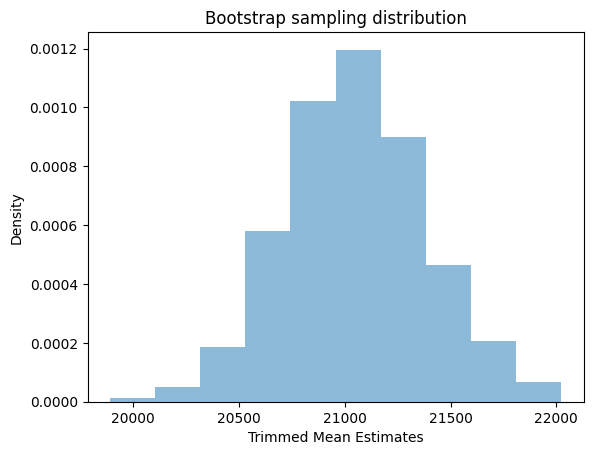

In [38]:
# plot an histogram of the bootstrap sampling distribution
plt.hist(result, density=True, label='Histogram of bootstrap estimates', alpha=0.5)
plt.xlabel('Trimmed Mean Estimates')
plt.ylabel('Density')
plt.title("Bootstrap sampling distribution")    

Remark: the trimmed mean bootstrap sampling distribution is closer to a Gaussian that the Bootstrap sampling distribution of the empirical median. Intuitively it is because the trimmed mean is close to the mean for which we have the CLT that assure us approximate Gaussian behavior. The empirical median also has approximate Gaussian behavior but the approximation is more crude than for the mean.

In [39]:
bias = np.mean(result)-T_hat # Compute the bias of the bootstrap sampling distribution
variance = np.var(result, ddof=1) # Compute the variance of the bootstrap sampling distribution
print('An estimation of the bias is given by: %.2F km/s' % (bias))
print('An estimation of the standard deviation is given by: %.2F km/s' % (np.sqrt(variance)))

An estimation of the bias is given by: -19.22 km/s
An estimation of the standard deviation is given by: 333.22 km/s


In [42]:
q1 = np.quantile(result-T_hat, 0.05) # Compute the 0.05 quantile of the bootstrap sampling distribution
q2 = np.quantile(result-T_hat,0.95)# Compute the 0.95 quantile of the bootstrap sampling distribution
print("The confidence interval of M is [%.2F,%.2F]" % (T_hat - q2, T_hat - q1))

The confidence interval of M is [20515.45,21619.51]
